In [1]:
%load_ext autoreload
%autoreload 

import numpy as np
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
print("Jax version", jax.__version__)
import distrax
print("Distrax version", distrax.__version__)
import flax
import flax.nnx as nnx
print("Flax version", flax.__version__)
import optax 
print("Optax version", optax.__version__)
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
print("PyTorch version", torch.__version__)

from sbi_compression.methods.linear.CCA import CCA
from sbi_compression.methods.data import dataset_shapes

Jax version 0.10.0
Distrax version 0.1.8
Flax version 0.12.7
Optax version 0.2.8
PyTorch version 2.12.0


In [2]:
# with np.load('../sbi_lens_sims/mpi_job_4483820_combined.npz') as data:
with np.load('../sbi_lens_sims/combined_overall.npz') as data:
    x = data['y']
    # Flax Conv layers expects data shape in (N, H, W, C) format
    p = data['theta']
    # Remove any NaN data points
    nan_mask = jnp.isnan(x).reshape(x.shape[0], -1).any(axis=1)
    clean_indices = jnp.where(~nan_mask)[0]
    x = x[clean_indices]
    p = p[clean_indices]
    N_data = x.shape[0]
    print("x", x.shape, "\np", p.shape)

x (66295, 60, 60, 5) 
p (66295, 6)


In [6]:
# Truth vs Latent diagnostic scatter
gt = ground_truth = p
canonical_variables = CCA(p,x,regularisation=0)
cd = compressed_data = canonical_variables[0]
canonical_variables = canonical_variables[1]
results = {
    "ground_truth": gt,
    "compressed_data": cd,
    "canonical_params": canonical_variables,
}
path = f"compressed_data/CCA_sbi_lens.pkl"
with open(path, 'wb') as f:
    pickle.dump(results, f)
print(compressed_data.shape, p.shape)
print("Canonical correlations", canonical_variables[2])

'data2' is the higher dimensional data that will be compressed.
(66295, 6) (66295, 6)
Canonical correlations [nan nan nan nan nan nan]


In [5]:
# Truth vs Latent diagnostic scatter
params = ['Oc','Ob','s8','h0','Ns','w0']
num_params = ground_truth.shape[1]
print(cd.shape, p.shape)
print(cd)

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cd[:,i], s=1, color="blue")
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'Latent {params[i]}')

plt.suptitle("flax.nnx MSE compressor")
plt.tight_layout()
# plt.savefig(f"nnx_MSE_scatter_{STEPS}_steps.pdf")
plt.show()

NameError: name 'cd' is not defined

'data2' is the higher dimensional data that will be compressed.
[[ 2.90528685e-02  1.53695473e-05 -2.65906565e-04 -3.35904406e-05
   2.67938420e-04  6.65474101e-04 -1.06496618e-05 -1.13122987e-04
   4.28831809e-05  6.22892694e-05  2.02369876e-04 -1.25711813e-04
   9.53321796e-05  7.34593050e-06  1.01993610e-04  1.80058676e-04
   5.05574390e-05  8.04425363e-05 -1.31316910e-05  4.70340528e-05
   1.01867183e-04  1.62350796e-06  1.56778697e-05  5.88133407e-05
  -1.06249609e-05 -4.71934618e-05  3.69157096e-05  1.02935381e-04
   2.71250592e-05  3.34824144e-05]
 [ 1.53695473e-05  3.62958926e-05  1.31738000e-06  6.51624941e-06
   8.36097843e-06  5.03949605e-06 -9.75925786e-07 -6.24843835e-07
   1.86856346e-06 -5.09871188e-06 -6.42221437e-07 -1.52295991e-06
  -5.51353253e-07  2.84953990e-06  1.16812248e-06 -2.19195044e-06
  -1.06916912e-06 -4.28350995e-06 -9.06537878e-07 -2.50143921e-06
   1.46576508e-06  6.78292452e-07 -9.46103171e-07  1.25294786e-09
   3.87676300e-06 -1.20614061e-07 -3.108594

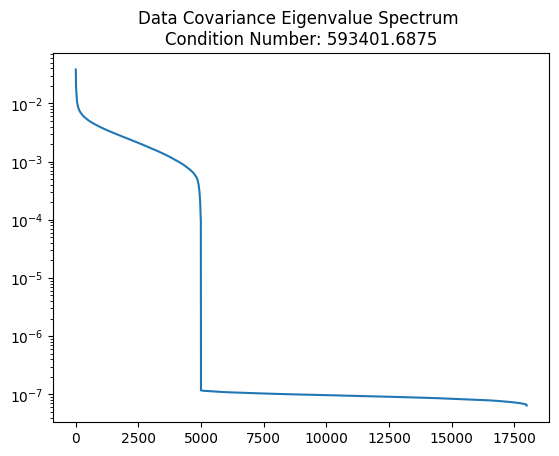

[0.9999671  0.9999537  0.9999494  0.9999413  0.9999246  0.99720234]
[0.99998355 0.9999768  0.99997467 0.9999706  0.9999623  0.9986002 ]
(66295, 6) (66295, 6)
Canonical correlations [0.99998355 0.9999768  0.99997467 0.9999706  0.9999623  0.9986002 ]


In [5]:
import jax
import jax.numpy as jnp
import jax.numpy.linalg as jla
from sbi_compression.methods.data import dataset_shapes, flatten_features   
    
# @jax.jit
def CCA(data1, data2, regularisation=0.0, data_cov_check: bool = True):
    """
    Canonical Correlation Analysis. 
    The compressed data dimension is the minimum of the dimensions of data1 and data2.

    Parameters
    ----------
    data1: jax.Array
        Data array of shape (n_samples, feature_shape1) e.g. parameters.
    data2: jax.Array
        Paired data array data1 of shape (n_samples, feature_shape2) e.g. simulations.
    regularisation: float
        Regularisation parameter to prevent the covariance matrices from being singular.

    Returns
    -------
    tuple of jax.Array
        A 5-tuple ``(compressed_data, compressed_params, canonical_correlations, canonical_t_directions, canonical_p_directions)`` with:
        - `compressed_data`: The compressed data array of shape (n_samples, min(feature_shape1, feature_shape2)).
        - `compressed_params`: The compressed parameters array of shape (n_samples, min(feature_shape1, feature_shape2)).
        - `canonical_correlations`: The canonical correlations of shape (min(feature_shape1, feature_shape2),).
        - `canonical_t_directions`: The canonical directions for the data array of shape (feature_shape2, min(feature_shape1, feature_shape2)).
        - `canonical_p_directions`: The canonical directions for the parameters array of shape (feature_shape1, min(feature_shape1, feature_shape2)).   
    Raises
    ------
    ValueError
        If data1 and data2 have different number of samples.

    Examples
    --------
    >>> CCA(data1, data2)
    """
    n_samples1, feature_shape1 = dataset_shapes(data1)
    n_samples2, feature_shape2 = dataset_shapes(data2)
    if n_samples1 != n_samples2:
        raise ValueError("The paired dataset (data1, data2) have different number of samples.")
    
    # Flatten the features if 2D
    data1, data2 = flatten_features(data1), flatten_features(data2)
    n_features1, n_features2 = dataset_shapes(data1)[1][0], dataset_shapes(data2)[1][0]
    if n_features1 > n_features2:
        raise ValueError("The flattened dimension of data1 is greater than the flattened dimension of data2. The higher dimensional data should be the data1.")

    # Rename the variables 
    # The higher dimensional data would be the 'data' vesctor 't'
    # The lower dimensional data would be the 'parameter' vector 'p'
    if n_features1 > n_features2:
        data_t, data_p = data1, data2
        t_dim, p_dim = n_features1, n_features2
        print("'data1' is the higher dimensional data that will be compressed.")
    elif n_features1 == n_features2:
        data_p, data_t = data1, data2
        p_dim, t_dim = n_features1, n_features2
        print("The flattened dimensions of 'data1' and 'data2' are the same. We will compress 'data1'.")
    else:
        data_p, data_t = data1, data2
        p_dim, t_dim = n_features1, n_features2
        print("'data2' is the higher dimensional data that will be compressed.")

    # Implemented following the method in https://github.com/98minsu/CosmoCompression/blob/main/notebook.ipynb
    # cov_cca is composed of the covariance matrices of data_p and data_t, and the cross-covariance matrix between data_p and data_t.
    # [[ cov_p    , cov_pt ],
    #  [ cov_pt.T , cov_t  ]]
    cov_cca = jnp.cov(data_p.T, data_t.T)
    print(cov_cca[:30,:30])
    cov_p = cov_cca[:p_dim, :p_dim] + regularisation * jnp.eye(p_dim)
    cov_t = cov_cca[p_dim:, p_dim:] + regularisation * jnp.eye(t_dim)
    cov_pt = cov_cca[:p_dim, p_dim:]
    # cov_l = cov_pt.T @ jla.inv(cov_p) @ cov_pt # cov_tp is the transpose of cov_pt by symmetry of the covariance matrix
    # evals, evecs = jsla.eigh(cov_t, cov_t-cov_l) # use .eigh since the covariance matrices are symmetric
    # Try this in a cell to see why it fails
    if data_cov_check == True:
        evals_check = jnp.linalg.eigvalsh(cov_t)
        plt.plot(evals_check[::-1])
        plt.yscale('log')
        plt.title(f"Data Covariance Eigenvalue Spectrum \nCondition Number: {evals_check[-1] / evals_check[0]}")
        plt.show()
    # Since the covariance matrices are symmetric and jax does not support generalized eigenvalue decomposition
    # We can use the Cholesky decomposition to solve the generalized eigenvalue problem.
    cov_l = cov_pt.T @ jla.inv(cov_p) @ cov_pt
    # B = cov_t - cov_l
    B = cov_t
    L = jnp.linalg.cholesky(B)
    Linv = jla.inv(L)
    # Transform to a standard eigenvalue problem: C = Linv @ A @ Linv.T
    # C = Linv @ cov_t @ Linv.T
    C = Linv @ cov_l @ Linv.T
    evals, evecs_standard = jla.eigh(C)
    # Back-transform eigenvectors: v = (L^T)^-1 @ evecs_standard
    evecs = jla.solve(L.T, evecs_standard)

    # In the context of the CCA, only min( dim(param), dim(data vector) ) components are real and the rest are noise. 
    evals = evals[::-1][:p_dim]
    print(evals)
    evecs = evecs[:,::-1][:,:p_dim]

    # Transform data vector into the canonical space
    canonical_t_directions = evecs
    compressed_data = data_t @ evecs

    # Transform the parameters into the canonical space
    # canon_corr = jnp.sqrt(evals/(1+evals))
    canon_corr = jnp.sqrt(evals)
    print(canon_corr)
    canonical_p_directions = jla.inv(cov_p) @ cov_pt @ evecs @ jnp.diag(1/jnp.sqrt(evals))
    compressed_params = data_p @ canonical_p_directions

    return compressed_data, compressed_params, canon_corr, canonical_t_directions, canonical_p_directions


# Truth vs Latent diagnostic scatter
gt = ground_truth = p
canonical_variables = CCA(p,x,regularisation=1e-7)
cd = compressed_data = canonical_variables[0]
canonical_params = canonical_variables[1]
results = {
    "ground_truth": gt,
    "compressed_data": cd,
    "canonical_params": canonical_params,
}
path = f"compressed_data/CCA_sbi_lens.pkl"
with open(path, 'wb') as f:
    pickle.dump(results, f)
print(compressed_data.shape, p.shape)
print("Canonical correlations", canonical_variables[2])